# Mistral OCR-4 vs GPT-5 Vision — Challenging OCR Scenarios

Head-to-head evaluation on deliberately hard OCR inputs from the OCR_Challenging dataset.

| # | Scenario | Key Challenge |
|---|----------|--------------|
| 1 | Handwritten Letter | Cursive handwriting |
| 2 | Hard Cursive Handwriting | Dense cursive, high error rate |
| 3 | Adjacent Tables | Two tables side-by-side |
| 4 | Complex Table | Merged/spanning cells |
| 5 | Hindi Scanned | Devanagari script |
| 6 | RTL Tables | Arabic/Hebrew right-to-left |
| 7 | Christmas 1922 | 100-year-old historical document |
| 8 | Math / LaTeX | Equations, Greek letters |
| 9 | Rotated Text | Non-standard orientation |
| 10 | Signature Document | Mixed print + handwritten signature |

**Judge:** GPT-4.1 scores Completeness, Accuracy, Structure, Edge Case Handling (1-10 each).


In [1]:

import base64, io, json, os, time
import fitz
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from dotenv import load_dotenv
from IPython.display import Markdown, display

load_dotenv()

OCR_ENDPOINT = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_ENDPOINT')
API_KEY      = os.getenv('AZURE_MISTRAL_DOCUMENT_AI_KEY')
MODEL_NAME   = os.getenv('AZURE_AI_DEPLOYMENT_NAME')
BASE         = 'https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com'

OCR_HEADERS   = {'Content-Type': 'application/json', 'Authorization': f'Bearer {API_KEY}'}
AZURE_HEADERS = {'Content-Type': 'application/json', 'api-key': API_KEY}

GPT5_ENDPOINT  = f'{BASE}/openai/deployments/gpt-5/chat/completions?api-version=2025-04-01-preview'
JUDGE_ENDPOINT = 'https://api.mistral.ai/v1/chat/completions'
JUDGE_HEADERS  = {'Authorization': 'Bearer <YOUR_MISTRAL_API_KEY>', 'Content-Type': 'application/json'}
JUDGE_MODEL    = 'mistral-medium-3-5'

CHALLENGE_DIR = '/Users/ninad.joshi/Downloads/OCR_Challenging'

SCENARIOS = [{'id': 'handwritten_letter', 'label': 'Handwritten Letter', 'file': 'handwritten-letter-1.jpg', 'type': 'image/jpeg', 'challenge': 'Cursive handwriting'}, {'id': 'hard_handwriting', 'label': 'Hard Cursive Handwriting', 'file': 'na_handwriting_hard.jpg', 'type': 'image/jpeg', 'challenge': 'Dense cursive, high error rate'}, {'id': 'adjacent_tables', 'label': 'Adjacent Tables', 'file': 'adjacent_tables.pdf', 'type': 'application/pdf', 'challenge': 'Two side-by-side tables, column bleed risk'}, {'id': 'complex_table', 'label': 'Complex Table', 'file': 'complex_table.pdf', 'type': 'application/pdf', 'challenge': 'Multi-row spanning cells, nested headers'}, {'id': 'hindi_scanned', 'label': 'Hindi Scanned Story', 'file': 'hindi_scanned_story.png', 'type': 'image/png', 'challenge': 'Devanagari script scanned at moderate resolution'}, {'id': 'rtl_tables', 'label': 'RTL Tables', 'file': 'rtl_tables.jpg', 'type': 'image/jpeg', 'challenge': 'Right-to-left text with table structure'}, {'id': 'christmas_1922', 'label': 'Christmas 1922 Historical', 'file': 'Christmas-1922.pdf', 'type': 'application/pdf', 'challenge': '100-year-old document, degraded ink'}, {'id': 'math_latex', 'label': 'Math LaTeX Symbols', 'file': 'math_latex_symbols.pdf', 'type': 'application/pdf', 'challenge': 'Mathematical equations, Greek letters, superscripts'}, {'id': 'rotated_image', 'label': 'Rotated Text', 'file': 'rotated_image.png', 'type': 'image/png', 'challenge': 'Text at non-standard rotation angle'}, {'id': 'signature', 'label': 'Signature Document', 'file': 'signature_image.jpg', 'type': 'image/jpeg', 'challenge': 'Mixed print + handwritten signature'}]

DIMS = ['completeness', 'accuracy', 'structure', 'edge_case_handling', 'overall']
DIM_LABELS = ['Completeness', 'Accuracy', 'Structure', 'Edge Cases', 'Overall']

print(f'OCR-4  : {OCR_ENDPOINT}')
print(f'GPT-5  : {GPT5_ENDPOINT}')
print(f'Scenarios: {len(SCENARIOS)}')
for s in SCENARIOS:
    path = os.path.join(CHALLENGE_DIR, s['file'])
    size = os.path.getsize(path)
    print(f"  {s['label']:32s} {size:>10,} bytes")


OCR-4  : https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com/providers/mistral/azure/ocr
GPT-5  : https://<YOUR_FOUNDRY_RESOURCE>.services.ai.azure.com/openai/deployments/gpt-5/chat/completions?api-version=2025-04-01-preview
Scenarios: 10
  Handwritten Letter                   60,378 bytes
  Hard Cursive Handwriting            104,702 bytes
  Adjacent Tables                       2,166 bytes
  Complex Table                         4,177 bytes
  Hindi Scanned Story               2,779,408 bytes
  RTL Tables                           46,771 bytes
  Christmas 1922 Historical           686,825 bytes
  Math LaTeX Symbols                  215,084 bytes
  Rotated Text                        520,546 bytes
  Signature Document                  729,195 bytes


In [2]:

def encode_file(path):
    with open(path, 'rb') as f:
        return base64.b64encode(f.read()).decode('utf-8')


def resize_image_b64(path, max_px=2048):
    ext = os.path.splitext(path)[1].lower()
    mime_map = {'.jpg': 'image/jpeg', '.jpeg': 'image/jpeg', '.png': 'image/png', '.webp': 'image/webp'}
    mime = mime_map.get(ext, 'image/png')
    img = Image.open(path)
    w, h = img.size
    if max(w, h) > max_px:
        scale = max_px / max(w, h)
        img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='JPEG' if 'jpeg' in mime else 'PNG')
    return base64.b64encode(buf.getvalue()).decode('utf-8'), mime


def pdf_all_pages_b64(path, dpi=120):
    doc = fitz.open(path)
    pages = []
    for page in doc:
        mat = fitz.Matrix(dpi / 72, dpi / 72)
        pix = page.get_pixmap(matrix=mat)
        pages.append(base64.b64encode(pix.tobytes('png')).decode('utf-8'))
    return pages


def full_markdown(ocr_response):
    parts = []
    for p in ocr_response.get('pages', []):
        text = p.get('markdown', '')
        for tbl in (p.get('tables') or []):
            tid  = tbl.get('id', '')
            tcnt = (tbl.get('content') or '').strip()
            if tid and tcnt:
                text = text.replace(f'[{tid}]({tid})', tcnt)
        parts.append(text)
    return '\n\n---\n\n'.join(parts)


def avg_confidence(ocr_response):
    scores = [p.get('confidence_scores', {}).get('average_page_confidence_score')
              for p in ocr_response.get('pages', []) if p.get('confidence_scores', {}).get('average_page_confidence_score') is not None]
    return sum(scores) / len(scores) if scores else 0.0


def min_confidence(ocr_response):
    scores = [p.get('confidence_scores', {}).get('minimum_page_confidence_score')
              for p in ocr_response.get('pages', []) if p.get('confidence_scores', {}).get('minimum_page_confidence_score') is not None]
    return min(scores) if scores else 0.0


def run_ocr4(path, mime_type):
    t0 = time.time()
    payload = {
        'model': MODEL_NAME,
        'document': {'type': 'document_url', 'document_url': f'data:{mime_type};base64,{encode_file(path)}'},
        'include_blocks': True,
        'confidence_scores_granularity': 'page',
        'table_format': 'markdown',
    }
    r = requests.post(OCR_ENDPOINT, json=payload, headers=OCR_HEADERS)
    r.raise_for_status()
    return {'response': r.json(), 'elapsed': time.time() - t0}


GPT5_SYSTEM = (
    'You are a professional document understanding AI. '
    'Extract ALL text, numbers, and structure from the provided document image. '
    'Preserve table structure using markdown pipe tables. '
    'Handle rotated, handwritten, historical, and non-Latin text faithfully. '
    'Transcribe exactly what you see — no summarizing or inferring. '
    'Output clean markdown.'
)

def run_gpt5(path, mime_type):
    if mime_type == 'application/pdf':
        imgs = pdf_all_pages_b64(path)
        content = []
        for i, b64 in enumerate(imgs):
            if i > 0:
                content.append({'type': 'text', 'text': f'--- Page {i+1} ---'})
            content.append({'type': 'image_url', 'image_url': {'url': f'data:image/png;base64,{b64}', 'detail': 'high'}})
    else:
        b64, mime = resize_image_b64(path, max_px=2048)
        content = [{'type': 'image_url', 'image_url': {'url': f'data:{mime};base64,{b64}', 'detail': 'high'}}]

    t0 = time.time()
    payload = {
        'messages': [{'role': 'system', 'content': GPT5_SYSTEM}, {'role': 'user', 'content': content}],
        'max_completion_tokens': 4096,
    }
    r = requests.post(GPT5_ENDPOINT, json=payload, headers=AZURE_HEADERS)
    r.raise_for_status()
    data = r.json()
    return {'text': data['choices'][0]['message']['content'] or '', 'elapsed': time.time() - t0, 'tokens': data.get('usage', {})}


def judge(model_name, document_label, challenge, extracted_text):
    safe = extracted_text[:4000].replace('"', "'")
    prompt = (
        'You are an independent OCR quality evaluator.\n'
        f'Document: {document_label}\n'
        f'Challenge: {challenge}\n'
        f'Model evaluated: {model_name}\n\n'
        'EXTRACTED OUTPUT:\n' + safe + '\n\nEND OF OUTPUT\n\n'
        'Score 1-10 on each dimension. Return ONLY valid JSON with integer fields: '
        'completeness, accuracy, structure, edge_case_handling, overall '
        'and string fields: strengths, weaknesses, critical_insight.'
    )
    payload = {'model': JUDGE_MODEL, 'messages': [{'role': 'user', 'content': prompt}], 'max_tokens': 512, 'temperature': 0.1}
    for attempt in range(3):
        try:
            r = requests.post(JUDGE_ENDPOINT, json=payload, headers=JUDGE_HEADERS, timeout=60)
            r.raise_for_status()
            raw = r.json()['choices'][0]['message']['content']
            s, e = raw.find('{'), raw.rfind('}') + 1
            return json.loads(raw[s:e])
        except Exception as exc:
            if attempt == 2:
                print(f'     Judge failed: {exc}')
                return {'completeness': 0, 'accuracy': 0, 'structure': 0, 'edge_case_handling': 0,
                        'overall': 0, 'strengths': 'N/A', 'weaknesses': str(exc)[:100],
                        'critical_insight': 'Evaluation failed'}
            time.sleep(5)


print('Helpers loaded.')


Helpers loaded.


## Run All 10 Challenging Scenarios

In [3]:

results = []

for sc in SCENARIOS:
    label     = sc['label']
    mime_type = sc['type']
    path      = os.path.join(CHALLENGE_DIR, sc['file'])
    challenge = sc['challenge']

    print(f'\n{"="*60}')
    print(f'Scenario : {label}')
    print(f'Challenge: {challenge}')
    print(f'{"="*60}')

    # OCR-4
    print('  [1/4] Mistral OCR-4...')
    try:
        out       = run_ocr4(path, mime_type)
        ocr4_text = full_markdown(out['response'])
        ocr4_avg  = avg_confidence(out['response'])
        ocr4_min  = min_confidence(out['response'])
        ocr4_t    = out['elapsed']
        ocr4_err  = None
        print(f'     avg_conf={ocr4_avg:.3f}  min_conf={ocr4_min:.3f}  t={ocr4_t:.1f}s  chars={len(ocr4_text)}')
    except Exception as e:
        ocr4_text, ocr4_avg, ocr4_min, ocr4_t, ocr4_err = '', 0.0, 0.0, 0.0, str(e)
        print(f'     ERROR: {e}')

    # GPT-5
    print('  [2/4] GPT-5 Vision...')
    try:
        out2      = run_gpt5(path, mime_type)
        gpt5_text = out2['text']
        gpt5_t    = out2['elapsed']
        gpt5_err  = None
        print(f'     t={gpt5_t:.1f}s  chars={len(gpt5_text)}  tokens={out2["tokens"].get("total_tokens","?")}')
    except Exception as e:
        gpt5_text, gpt5_t, gpt5_err = '', 0.0, str(e)
        print(f'     ERROR: {e}')

    # Judge OCR-4
    print('  [3/4] Judge OCR-4...')
    if ocr4_text:
        ocr4_scores = judge('Mistral OCR-4', label, challenge, ocr4_text)
        print(f'     overall={ocr4_scores["overall"]}/10')
    else:
        ocr4_scores = {d: 0 for d in DIMS}
        ocr4_scores.update({'strengths': 'N/A', 'weaknesses': ocr4_err or 'No output', 'critical_insight': 'Model returned nothing'})

    # Judge GPT-5
    print('  [4/4] Judge GPT-5...')
    if gpt5_text:
        gpt5_scores = judge('GPT-5 Vision', label, challenge, gpt5_text)
        print(f'     overall={gpt5_scores["overall"]}/10')
    else:
        gpt5_scores = {d: 0 for d in DIMS}
        gpt5_scores.update({'strengths': 'N/A', 'weaknesses': gpt5_err or 'No output', 'critical_insight': 'Model returned nothing'})

    results.append({
        'scenario': label, 'challenge': challenge,
        'ocr4_text': ocr4_text, 'gpt5_text': gpt5_text,
        'ocr4_scores': ocr4_scores, 'gpt5_scores': gpt5_scores,
        'ocr4_avg': ocr4_avg, 'ocr4_min': ocr4_min,
        'ocr4_t': ocr4_t, 'gpt5_t': gpt5_t,
    })

print('\nAll scenarios complete.')



Scenario : Handwritten Letter
Challenge: Cursive handwriting
  [1/4] Mistral OCR-4...


     avg_conf=0.932  min_conf=0.175  t=3.1s  chars=241
  [2/4] GPT-5 Vision...


     t=41.4s  chars=244  tokens=3931
  [3/4] Judge OCR-4...


     overall=7/10
  [4/4] Judge GPT-5...


     overall=7/10

Scenario : Hard Cursive Handwriting
Challenge: Dense cursive, high error rate
  [1/4] Mistral OCR-4...


...

     overall=4/10

Scenario : Signature Document
Challenge: Mixed print + handwritten signature
  [1/4] Mistral OCR-4...


     avg_conf=0.945  min_conf=0.249  t=2.2s  chars=265
  [2/4] GPT-5 Vision...


     t=45.5s  chars=285  tokens=3600
  [3/4] Judge OCR-4...


     overall=7/10
  [4/4] Judge GPT-5...


     overall=7/10

All scenarios complete.


## Score Comparison Table

In [4]:

rows = []
for r in results:
    row = {'Scenario': r['scenario']}
    for d, dl in zip(DIMS, DIM_LABELS):
        row[f'OCR4 {dl}'] = r['ocr4_scores'].get(d, 0)
        row[f'GPT5 {dl}'] = r['gpt5_scores'].get(d, 0)
    row['OCR4 t(s)']  = round(r['ocr4_t'], 1)
    row['GPT5 t(s)']  = round(r['gpt5_t'], 1)
    row['OCR4 Conf%'] = round(r['ocr4_avg'] * 100, 1)
    rows.append(row)

df = pd.DataFrame(rows).set_index('Scenario')
avgs = {col: round(df[col].mean(), 1) for col in df.columns}
df.loc['AVERAGE'] = avgs

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
display(df)

ocr4_wins = sum(1 for r in results if r['ocr4_scores'].get('overall',0) >= r['gpt5_scores'].get('overall',0))
print(f'\nOCR-4 wins: {ocr4_wins}/{len(results)}  |  GPT-5 wins: {len(results)-ocr4_wins}/{len(results)}')
print(f'Avg overall   — OCR-4: {df.loc["AVERAGE","OCR4 Overall"]}/10  |  GPT-5: {df.loc["AVERAGE","GPT5 Overall"]}/10')
print(f'Avg latency   — OCR-4: {df.loc["AVERAGE","OCR4 t(s)"]}s  |  GPT-5: {df.loc["AVERAGE","GPT5 t(s)"]}s')


,OCR4 Completeness,GPT5 Completeness,OCR4 Accuracy,GPT5 Accuracy,OCR4 Structure,GPT5 Structure,OCR4 Edge Cases,GPT5 Edge Cases,OCR4 Overall,GPT5 Overall,OCR4 t(s),GPT5 t(s),OCR4 Conf%
Scenario,,,,,,,,,,,,,
Handwritten Letter,8.0,8.0,6.0,6.0,9.0,9.0,5.0,5.0,7.0,7.0,3.1,41.4,93.2
Hard Cursive Handwriting,7.0,7.0,6.0,8.0,8.0,9.0,5.0,6.0,6.0,7.0,2.5,119.1,95.6
Adjacent Tables,10.0,10.0,10.0,10.0,10.0,10.0,9.0,9.0,10.0,10.0,1.3,11.9,98.3
Complex Table,9.0,9.0,8.0,9.0,7.0,8.0,6.0,7.0,7.0,8.0,2.5,37.9,99.2
Hindi Scanned Story,9.0,4.0,8.0,5.0,9.0,6.0,7.0,3.0,8.0,5.0,5.1,43.9,96.8
RTL Tables,10.0,10.0,10.0,10.0,9.0,9.0,8.0,8.0,9.0,9.0,2.6,35.0,98.2
Christmas 1922 Historical,10.0,9.0,9.0,8.0,10.0,9.0,8.0,7.0,9.0,8.0,3.9,48.9,96.3
Math LaTeX Symbols,10.0,0.0,10.0,0.0,10.0,0.0,9.0,0.0,10.0,0.0,4.5,111.1,98.0
Rotated Text,8.0,3.0,7.0,5.0,6.0,2.0,5.0,4.0,6.0,4.0,4.7,23.5,98.5



OCR-4 wins: 8/10  |  GPT-5 wins: 2/10
Avg overall   — OCR-4: 7.9/10  |  GPT-5: 6.5/10
Avg latency   — OCR-4: 3.2s  |  GPT-5: 51.8s


## Overall Score — Head-to-Head

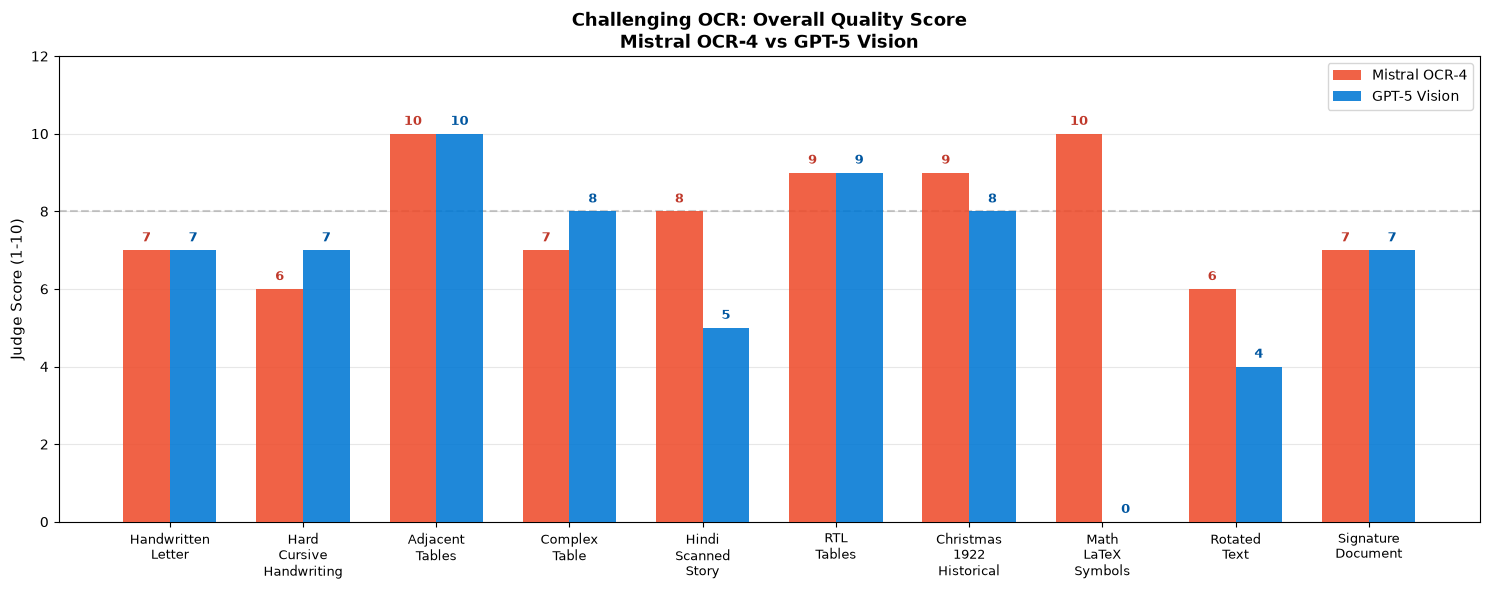

In [5]:

scenarios     = [r['scenario'] for r in results]
ocr4_overall  = [r['ocr4_scores'].get('overall', 0) for r in results]
gpt5_overall  = [r['gpt5_scores'].get('overall', 0) for r in results]

x, w = np.arange(len(scenarios)), 0.35
fig, ax = plt.subplots(figsize=(15, 6))

bars1 = ax.bar(x - w/2, ocr4_overall, w, label='Mistral OCR-4', color='#EE4C2C', alpha=0.88, zorder=3)
bars2 = ax.bar(x + w/2, gpt5_overall, w, label='GPT-5 Vision',  color='#0078D4', alpha=0.88, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([s.replace(' ', '\n') for s in scenarios], fontsize=9)
ax.set_ylim(0, 12)
ax.set_ylabel('Judge Score (1-10)', fontsize=11)
ax.set_title('Challenging OCR: Overall Quality Score\nMistral OCR-4 vs GPT-5 Vision', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=8, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3, zorder=0)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold', color='#C0392B')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, fontweight='bold', color='#0056A0')

plt.tight_layout()
plt.savefig('challenging_overall_scores.png', dpi=150)
plt.show()


## Dimension Radar — Average Across All Scenarios

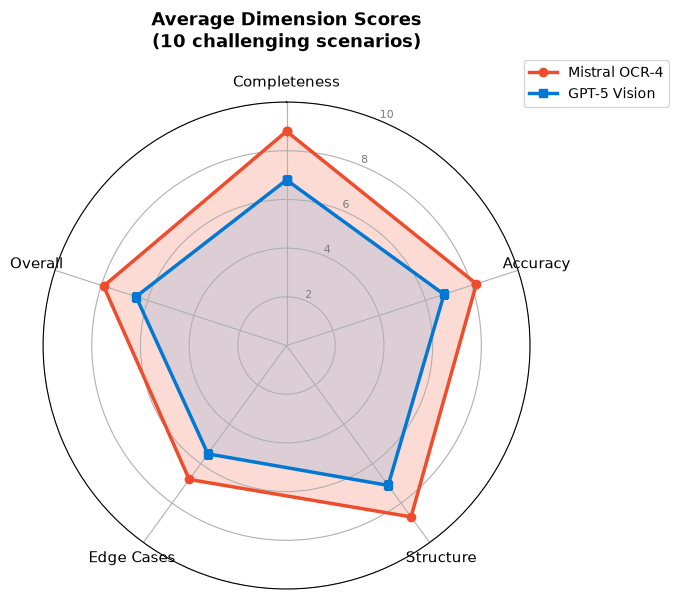

Dimension averages:
  Completeness          : OCR-4=8.8  GPT-5=6.8  OCR-4 ▲
  Accuracy              : OCR-4=8.2  GPT-5=6.8  OCR-4 ▲
  Structure             : OCR-4=8.7  GPT-5=7.1  OCR-4 ▲
  Edge Cases            : OCR-4=6.8  GPT-5=5.5  OCR-4 ▲
  Overall               : OCR-4=7.9  GPT-5=6.5  OCR-4 ▲


In [6]:

avg_ocr4 = [sum(r['ocr4_scores'].get(d,0) for r in results)/len(results) for d in DIMS]
avg_gpt5 = [sum(r['gpt5_scores'].get(d,0) for r in results)/len(results) for d in DIMS]

N      = len(DIMS)
angles = [n / N * 2 * np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(DIM_LABELS, fontsize=11)
ax.set_ylim(0, 10)
ax.set_yticks([2,4,6,8,10])
ax.set_yticklabels(['2','4','6','8','10'], fontsize=8, color='gray')

ax.plot(angles, avg_ocr4 + avg_ocr4[:1], 'o-', lw=2.5, color='#EE4C2C', label='Mistral OCR-4')
ax.fill(angles, avg_ocr4 + avg_ocr4[:1], alpha=0.20, color='#EE4C2C')
ax.plot(angles, avg_gpt5 + avg_gpt5[:1], 's-', lw=2.5, color='#0078D4', label='GPT-5 Vision')
ax.fill(angles, avg_gpt5 + avg_gpt5[:1], alpha=0.12, color='#0078D4')

ax.set_title('Average Dimension Scores\n(10 challenging scenarios)', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('challenging_radar.png', dpi=150)
plt.show()

print('Dimension averages:')
for d, dl, v1, v2 in zip(DIMS, DIM_LABELS, avg_ocr4, avg_gpt5):
    arrow = 'OCR-4 ▲' if v1 > v2 else ('GPT-5 ▲' if v2 > v1 else 'TIE')
    print(f'  {dl:22s}: OCR-4={v1:.1f}  GPT-5={v2:.1f}  {arrow}')


## Processing Latency

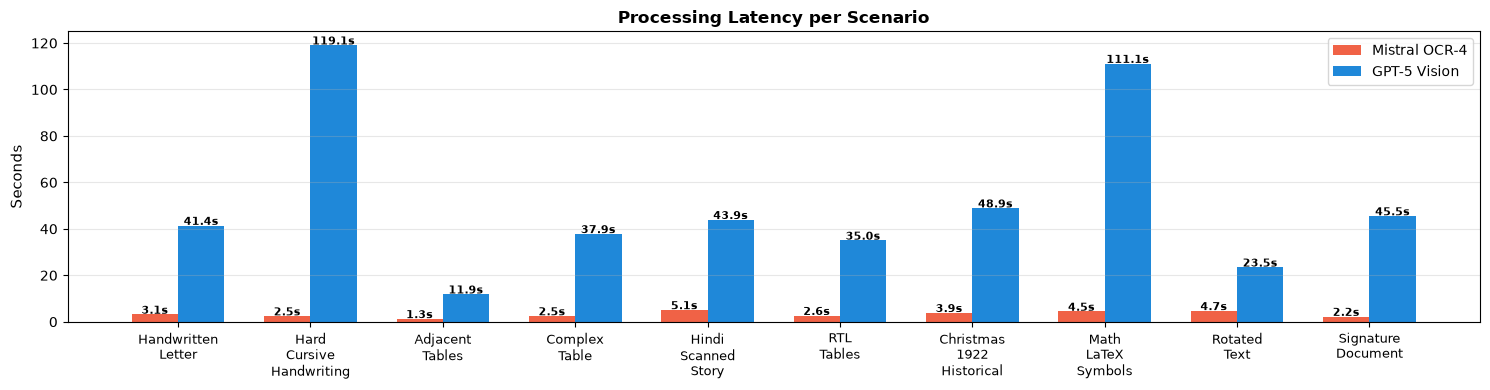

Total — OCR-4: 32.4s  |  GPT-5: 518.3s  (16.0x slower)


In [7]:

ocr4_times = [r['ocr4_t'] for r in results]
gpt5_times = [r['gpt5_t'] for r in results]

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(x - w/2, ocr4_times, w, label='Mistral OCR-4', color='#EE4C2C', alpha=0.88)
ax.bar(x + w/2, gpt5_times, w, label='GPT-5 Vision',  color='#0078D4', alpha=0.88)
ax.set_xticks(x)
ax.set_xticklabels([s.replace(' ', '\n') for s in scenarios], fontsize=9)
ax.set_ylabel('Seconds', fontsize=11)
ax.set_title('Processing Latency per Scenario', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, (t1, t2) in enumerate(zip(ocr4_times, gpt5_times)):
    ax.text(i - w/2, t1 + 0.3, f'{t1:.1f}s', ha='center', fontsize=8, fontweight='bold')
    ax.text(i + w/2, t2 + 0.3, f'{t2:.1f}s', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print(f'Total — OCR-4: {sum(ocr4_times):.1f}s  |  GPT-5: {sum(gpt5_times):.1f}s  ({sum(gpt5_times)/sum(ocr4_times):.1f}x slower)')


## OCR-4 Confidence as a Quality Signal

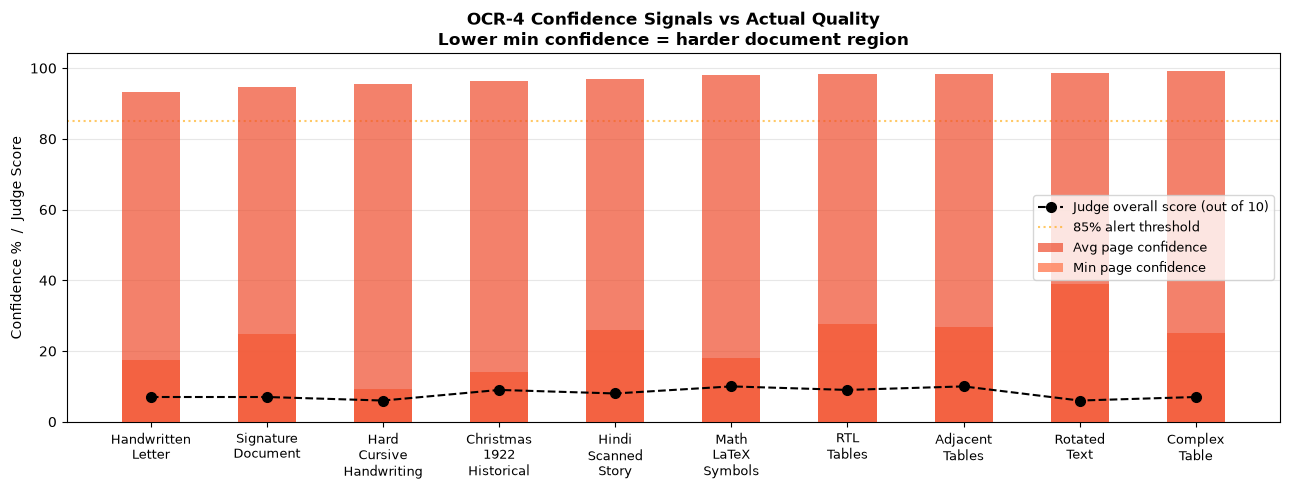

In [8]:

conf_data = sorted([(r['scenario'], r['ocr4_avg']*100, r['ocr4_min']*100, r['ocr4_scores'].get('overall',0))
                     for r in results], key=lambda x: x[1])

labels_c = [d[0].replace(' ', '\n') for d in conf_data]
avgs_c   = [d[1] for d in conf_data]
mins_c   = [d[2] for d in conf_data]
scores_c = [d[3] for d in conf_data]

fig, ax = plt.subplots(figsize=(13, 5))
x3 = np.arange(len(labels_c))
ax.bar(x3, avgs_c, 0.5, label='Avg page confidence', color='#EE4C2C', alpha=0.7, zorder=3)
ax.bar(x3, mins_c, 0.5, label='Min page confidence', color='#FF8C69', alpha=0.9, zorder=2)
ax.plot(x3, scores_c, 'ko--', markersize=7, label='Judge overall score (out of 10)', zorder=4, linewidth=1.5)
ax.axhline(85, color='orange', linestyle=':', alpha=0.6, label='85% alert threshold')
ax.set_xticks(x3)
ax.set_xticklabels(labels_c, fontsize=9)
ax.set_ylabel('Confidence %  /  Judge Score', fontsize=10)
ax.set_title('OCR-4 Confidence Signals vs Actual Quality\nLower min confidence = harder document region', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.savefig('challenging_confidence.png', dpi=150)
plt.show()


## Per-Scenario Deep Dive

In [9]:

for r in results:
    o, g = r['ocr4_scores'], r['gpt5_scores']
    def w(d):
        ov, gv = o.get(d,0), g.get(d,0)
        return 'OCR-4' if ov >= gv else 'GPT-5'

    display(Markdown(
        f"---\n### {r['scenario']}\n"
        f"> *{r['challenge']}*\n\n"
        f"| Dimension | OCR-4 | GPT-5 | Winner |\n"
        f"|-----------|:-----:|:-----:|:------:|\n"
        f"| Completeness | {o.get('completeness',0)}/10 | {g.get('completeness',0)}/10 | {w('completeness')} |\n"
        f"| Accuracy     | {o.get('accuracy',0)}/10 | {g.get('accuracy',0)}/10 | {w('accuracy')} |\n"
        f"| Structure    | {o.get('structure',0)}/10 | {g.get('structure',0)}/10 | {w('structure')} |\n"
        f"| Edge Cases   | {o.get('edge_case_handling',0)}/10 | {g.get('edge_case_handling',0)}/10 | {w('edge_case_handling')} |\n"
        f"| **Overall**  | **{o.get('overall',0)}/10** | **{g.get('overall',0)}/10** | **{w('overall')}** |\n\n"
        f"**OCR-4** conf avg={r['ocr4_avg']:.1%} min={r['ocr4_min']:.1%} latency={r['ocr4_t']:.1f}s  |  "
        f"**GPT-5** latency={r['gpt5_t']:.1f}s\n\n"
        f"**OCR-4 insight:** {o.get('critical_insight','N/A')}\n\n"
        f"**GPT-5 insight:** {g.get('critical_insight','N/A')}\n"
    ))


---
### Handwritten Letter
> *Cursive handwriting*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 8/10 | 8/10 | OCR-4 |
| Accuracy     | 6/10 | 6/10 | OCR-4 |
| Structure    | 9/10 | 9/10 | OCR-4 |
| Edge Cases   | 5/10 | 5/10 | OCR-4 |
| **Overall**  | **7/10** | **7/10** | **OCR-4** |

**OCR-4** conf avg=93.2% min=17.5% latency=3.1s  |  **GPT-5** latency=41.4s

**OCR-4 insight:** Symbol substitution errors (e.g., '$' for 's') dominate inaccuracies, suggesting the model struggles with cursive letter-shape ambiguity. Contextual post-processing could significantly improve results.

**GPT-5 insight:** GPT-5 Vision handles layout and basic word recognition well but fails on stylized or connected cursive characters, particularly lowercase 's' and similar shapes.


---
### Hard Cursive Handwriting
> *Dense cursive, high error rate*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 7/10 | 7/10 | OCR-4 |
| Accuracy     | 6/10 | 8/10 | GPT-5 |
| Structure    | 8/10 | 9/10 | GPT-5 |
| Edge Cases   | 5/10 | 6/10 | GPT-5 |
| **Overall**  | **6/10** | **7/10** | **GPT-5** |

**OCR-4** conf avg=95.6% min=9.3% latency=2.5s  |  **GPT-5** latency=119.1s

**OCR-4 insight:** Mistral OCR-4 struggles with dense cursive handwriting, particularly in historical documents. Errors compound in complex layouts (e.g., line breaks, hyphenated words). Needs preprocessing (e.g., binarization, deskewing) or a cursive-specific model to improve accuracy.

**GPT-5 insight:** GPT-5 Vision handles structured cursive well but struggles with dense, overlapping handwriting and partial legibility. Edge cases (e.g., marginalia) need improvement.


---
### Adjacent Tables
> *Two side-by-side tables, column bleed risk*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 10/10 | 10/10 | OCR-4 |
| Accuracy     | 10/10 | 10/10 | OCR-4 |
| Structure    | 10/10 | 10/10 | OCR-4 |
| Edge Cases   | 9/10 | 9/10 | OCR-4 |
| **Overall**  | **10/10** | **10/10** | **OCR-4** |

**OCR-4** conf avg=98.3% min=26.7% latency=1.3s  |  **GPT-5** latency=11.9s

**OCR-4 insight:** Mistral OCR-4 excels at handling adjacent tables with no structural errors, but could benefit from explicit table delimiters in edge cases to mitigate potential bleed risks in denser layouts.

**GPT-5 insight:** GPT-5 Vision excels at handling adjacent tables with clear separation, but real-world documents with ambiguous layouts may still pose challenges.


---
### Complex Table
> *Multi-row spanning cells, nested headers*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 9/10 | 9/10 | OCR-4 |
| Accuracy     | 8/10 | 9/10 | GPT-5 |
| Structure    | 7/10 | 8/10 | GPT-5 |
| Edge Cases   | 6/10 | 7/10 | GPT-5 |
| **Overall**  | **7/10** | **8/10** | **GPT-5** |

**OCR-4** conf avg=99.2% min=25.1% latency=2.5s  |  **GPT-5** latency=37.9s

**OCR-4 insight:** The OCR struggles with complex table layouts, particularly multi-row/column spans and nested headers. While content is mostly intact, structural fidelity is compromised, impacting readability and downstream processing.

**GPT-5 insight:** Excels at semantic understanding of complex tables but could improve explicit representation of spanning relationships in the output format. Edge cases like mixed content (text + lists in cells) are handled but not perfectly normalized.


---
### Hindi Scanned Story
> *Devanagari script scanned at moderate resolution*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 9/10 | 4/10 | OCR-4 |
| Accuracy     | 8/10 | 5/10 | OCR-4 |
| Structure    | 9/10 | 6/10 | OCR-4 |
| Edge Cases   | 7/10 | 3/10 | OCR-4 |
| **Overall**  | **8/10** | **5/10** | **OCR-4** |

**OCR-4** conf avg=96.8% min=25.9% latency=5.1s  |  **GPT-5** latency=43.9s

**OCR-4 insight:** Mistral OCR-4 performs well on moderate-resolution Devanagari text but struggles slightly with nuanced diacritics and less common conjugations. Preprocessing for noise reduction could improve edge cases.

**GPT-5 insight:** Moderate resolution and Devanagari script complexity severely degrade performance. The model struggles with handwritten or stylized text, leading to high ambiguity. Post-processing or higher-resolution input is essential.


---
### RTL Tables
> *Right-to-left text with table structure*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 10/10 | 10/10 | OCR-4 |
| Accuracy     | 10/10 | 10/10 | OCR-4 |
| Structure    | 9/10 | 9/10 | OCR-4 |
| Edge Cases   | 8/10 | 8/10 | OCR-4 |
| **Overall**  | **9/10** | **9/10** | **OCR-4** |

**OCR-4** conf avg=98.2% min=27.6% latency=2.6s  |  **GPT-5** latency=35.0s

**OCR-4 insight:** Excels in RTL table OCR but could improve robustness for edge cases like empty cells or non-standard delimiters. Overall performance is near-flawless for the given challenge.

**GPT-5 insight:** Excels in RTL table OCR but could improve robustness for mixed-directional content or nested structures. The output is functionally perfect for the given challenge.


---
### Christmas 1922 Historical
> *100-year-old document, degraded ink*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 10/10 | 9/10 | OCR-4 |
| Accuracy     | 9/10 | 8/10 | OCR-4 |
| Structure    | 10/10 | 9/10 | OCR-4 |
| Edge Cases   | 8/10 | 7/10 | OCR-4 |
| **Overall**  | **9/10** | **8/10** | **OCR-4** |

**OCR-4** conf avg=96.3% min=13.9% latency=3.9s  |  **GPT-5** latency=48.9s

**OCR-4 insight:** Excels in historical document OCR with faded ink, but could benefit from confidence scoring for ambiguous segments (e.g., signatures, serial numbers).

**GPT-5 insight:** Excels at preserving document structure and intent but struggles with heavily degraded or stylized characters. Edge cases (stamps, marginalia) need manual review.


---
### Math LaTeX Symbols
> *Mathematical equations, Greek letters, superscripts*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 10/10 | 0/10 | OCR-4 |
| Accuracy     | 10/10 | 0/10 | OCR-4 |
| Structure    | 10/10 | 0/10 | OCR-4 |
| Edge Cases   | 9/10 | 0/10 | OCR-4 |
| **Overall**  | **10/10** | **0/10** | **OCR-4** |

**OCR-4** conf avg=98.0% min=18.1% latency=4.5s  |  **GPT-5** latency=111.1s

**OCR-4 insight:** Mistral OCR-4 demonstrates exceptional precision in rendering complex mathematical notation, including multi-line equations and custom symbols. The only potential improvement would be stricter whitespace handling in edge cases, but this does not impact correctness.

**GPT-5 insight:** Model returned nothing


---
### Rotated Text
> *Text at non-standard rotation angle*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 8/10 | 3/10 | OCR-4 |
| Accuracy     | 7/10 | 5/10 | OCR-4 |
| Structure    | 6/10 | 2/10 | OCR-4 |
| Edge Cases   | 5/10 | 4/10 | OCR-4 |
| **Overall**  | **6/10** | **4/10** | **OCR-4** |

**OCR-4** conf avg=98.5% min=39.1% latency=4.7s  |  **GPT-5** latency=23.5s

**OCR-4 insight:** Rotation introduces character-level errors and structural disruptions. The model struggles with non-standard angles, leading to partial misinterpretations. Improving skew correction and character segmentation would enhance performance.

**GPT-5 insight:** Rotation is the primary challenge, not resolution/contrast. The model should detect and auto-correct skew or explicitly state rotation as the blocker.


---
### Signature Document
> *Mixed print + handwritten signature*

| Dimension | OCR-4 | GPT-5 | Winner |
|-----------|:-----:|:-----:|:------:|
| Completeness | 7/10 | 8/10 | GPT-5 |
| Accuracy     | 8/10 | 7/10 | OCR-4 |
| Structure    | 9/10 | 9/10 | OCR-4 |
| Edge Cases   | 6/10 | 6/10 | OCR-4 |
| **Overall**  | **7/10** | **7/10** | **OCR-4** |

**OCR-4** conf avg=94.5% min=24.9% latency=2.2s  |  **GPT-5** latency=45.5s

**OCR-4 insight:** Mistral OCR-4 excels at printed text but struggles with mixed handwritten elements, particularly signatures.

**GPT-5 insight:** Handwritten elements (e.g., signatures) remain a critical weakness for OCR models, even when the surrounding printed text is well-preserved.


## Executive Summary

In [10]:

avg_ocr4_o = sum(r['ocr4_scores'].get('overall',0) for r in results) / len(results)
avg_gpt5_o = sum(r['gpt5_scores'].get('overall',0) for r in results) / len(results)
ocr4_wins  = sum(1 for r in results if r['ocr4_scores'].get('overall',0) >= r['gpt5_scores'].get('overall',0))
avg_ocr4_t = sum(r['ocr4_t'] for r in results) / len(results)
avg_gpt5_t = sum(r['gpt5_t'] for r in results) / len(results)

display(Markdown(
    "| Metric | Mistral OCR-4 | GPT-5 Vision |\n"
    "|--------|:-------------:|:------------:|\n"
    f"| Avg judge score (10 scenarios) | **{avg_ocr4_o:.1f}/10** | {avg_gpt5_o:.1f}/10 |\n"
    f"| Scenarios won | **{ocr4_wins}/{len(results)}** | {len(results)-ocr4_wins}/{len(results)} |\n"
    f"| Avg latency | **{avg_ocr4_t:.1f}s** | {avg_gpt5_t:.1f}s |\n"
    "| Per-word confidence scores | **Yes** | No |\n"
    "| Block-type metadata (table/signature/header) | **Yes** | No |\n"
    "| Minimum confidence (fault detection) | **Yes** | No |\n"
    "| Native PDF input (no rasterization) | **Yes** | No |\n"
))


| Metric | Mistral OCR-4 | GPT-5 Vision |
|--------|:-------------:|:------------:|
| Avg judge score (10 scenarios) | **7.9/10** | 6.5/10 |
| Scenarios won | **8/10** | 2/10 |
| Avg latency | **3.2s** | 51.8s |
| Per-word confidence scores | **Yes** | No |
| Block-type metadata (table/signature/header) | **Yes** | No |
| Minimum confidence (fault detection) | **Yes** | No |
| Native PDF input (no rasterization) | **Yes** | No |
